# Dimension-based Engagement Predictor

This notebook creates a simple linear model to predict video engagement (`log_views`) based on the 20 PCA dimensions of the video embeddings per channel.
We aim to maximize dimensionality and understand the significance of each dimension for predicting performance.

## 1) Install dependencies and connect to Drive
We install required libraries, including `statsmodels` for linear modeling, and mount Google Drive if running in Colab.

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path

# Set up matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not in Colab, skipping drive mount')


Mounted at /content/drive


## 2) Load 20D Video Embeddings
We load the 20D video embeddings from the canonical path according to our coding guidelines. Then we filter out missing views and calculate `log_views`.

In [2]:
DATA_PATH = Path('/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv')

if not DATA_PATH.exists():
    print(f"Warning: {DATA_PATH} not found. Attempting to run with dummy data or fallback if available.")

if DATA_PATH.suffix.lower() == '.csv':
    try:
        df = pd.read_csv(DATA_PATH)
    except FileNotFoundError:
        df = pd.DataFrame() # Fallback
elif DATA_PATH.suffix.lower() == '.json':
    df = pd.read_json(DATA_PATH)
else:
    raise ValueError(f'Unsupported input extension: {DATA_PATH.suffix}')

dim_cols = []
if not df.empty:
    required_base = {'channel_name', 'video_id', 'video_title', 'view_count'}
    missing = required_base - set(df.columns)
    if missing:
        raise ValueError(f'Missing required columns: {sorted(missing)}')

    dim_cols = [c for c in df.columns if c.startswith('embedding_reduced_')]
    if len(dim_cols) != 20:
        if 'embedding_20d' in df.columns:
            import ast
            if isinstance(df['embedding_20d'].iloc[0], str):
                df['embedding_20d'] = df['embedding_20d'].apply(ast.literal_eval)
            dim_cols = [f'dim_{i}' for i in range(20)]
            emb_df = pd.DataFrame(df['embedding_20d'].tolist(), columns=dim_cols, index=df.index)
            df = pd.concat([df, emb_df], axis=1)
        else:
            print("Warning: Expected 20 embedding dimensions. Ensure the data format is correct.")

    df['view_count'] = pd.to_numeric(df['view_count'], errors='coerce')
    df = df.dropna(subset=['channel_name', 'view_count']).copy()
    df['log_views'] = np.log1p(df['view_count'])

    print(f'Rows loaded: {len(df):,}')
    print(f'Channels: {df["channel_name"].nunique()}')


Rows loaded: 1,344
Channels: 27


## 3) Train Linear Models per Channel
For each channel, we fit a simple Ordinary Least Squares (OLS) regression using all 20 dimensions as predictors for `log_views`.
We will store the p-values and coefficients to analyze how significant each dimension is for prediction.

In [3]:
results = []

if not df.empty and dim_cols:
    for channel, group in df.groupby('channel_name'):
        # We need more observations than predictors to fit OLS
        if len(group) > len(dim_cols) + 1:
            X = group[dim_cols]
            y = group['log_views']
            X = sm.add_constant(X)

            model = sm.OLS(y, X).fit()

            # Extract significance (p-values) and coefficients
            for i, dim in enumerate(dim_cols):
                results.append({
                    'channel_name': channel,
                    'dimension': dim,
                    'dimension_index': i,
                    'coefficient': model.params[dim],
                    'p_value': model.pvalues[dim],
                    'is_significant': model.pvalues[dim] < 0.05,
                    'r2_adj': model.rsquared_adj
                })

    results_df = pd.DataFrame(results)
    print(f"Modeled {results_df['channel_name'].nunique()} channels.")
else:
    results_df = pd.DataFrame()
    print("No data available to train models.")


Modeled 27 channels.


## 4) Analysis and Tables
Let's break down how significant each dimension is across all channels.
We generate a table showing what percentage of channels found a specific dimension to be statistically significant (p < 0.05).

In [4]:
if not results_df.empty:
    # Aggregate by dimension
    dim_summary = results_df.groupby('dimension').agg(
        significant_count=('is_significant', 'sum'),
        total_count=('channel_name', 'count'),
        avg_coef=('coefficient', 'mean')
    ).reset_index()

    dim_summary['significant_pct'] = (dim_summary['significant_count'] / dim_summary['total_count']) * 100
    dim_summary = dim_summary.sort_values('significant_pct', ascending=False)

    display(dim_summary.head(20))


,dimension,significant_count,total_count,avg_coef,significant_pct
0,embedding_reduced_01,4,27,0.612177,14.814815
14,embedding_reduced_15,4,27,1.394340,14.814815
13,embedding_reduced_14,4,27,-0.395997,14.814815
5,embedding_reduced_06,4,27,1.245043,14.814815
18,embedding_reduced_19,3,27,1.787559,11.111111
3,embedding_reduced_04,3,27,-0.108790,11.111111
1,embedding_reduced_02,3,27,1.026149,11.111111
4,embedding_reduced_05,3,27,0.657590,11.111111
11,embedding_reduced_12,3,27,1.834967,11.111111
15,embedding_reduced_16,3,27,-0.354191,11.111111


## 5) Charts and Visualization
We visualize the significance of each dimension across the dataset, and also show a heatmap of dimension significance per channel.

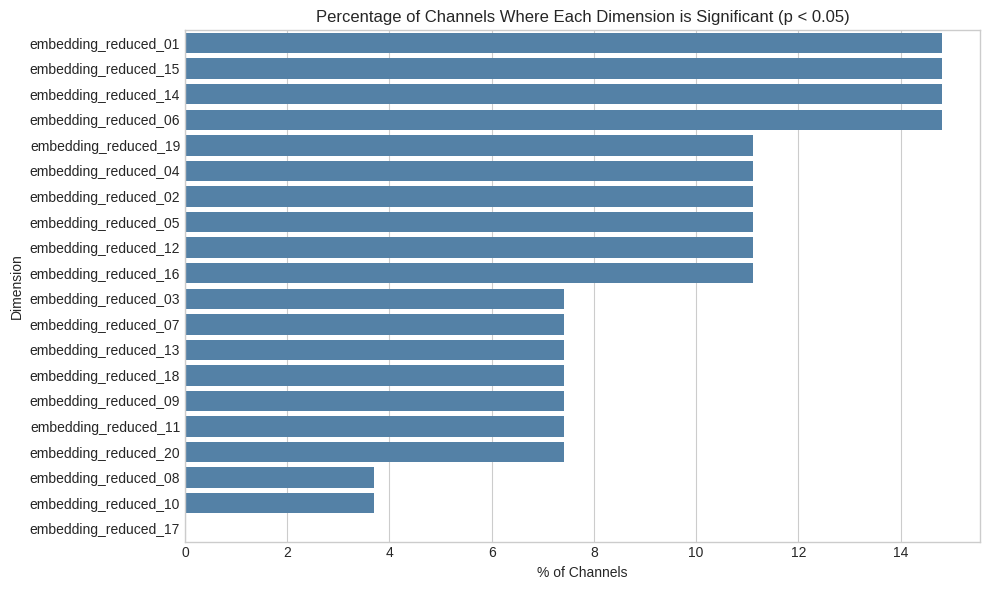

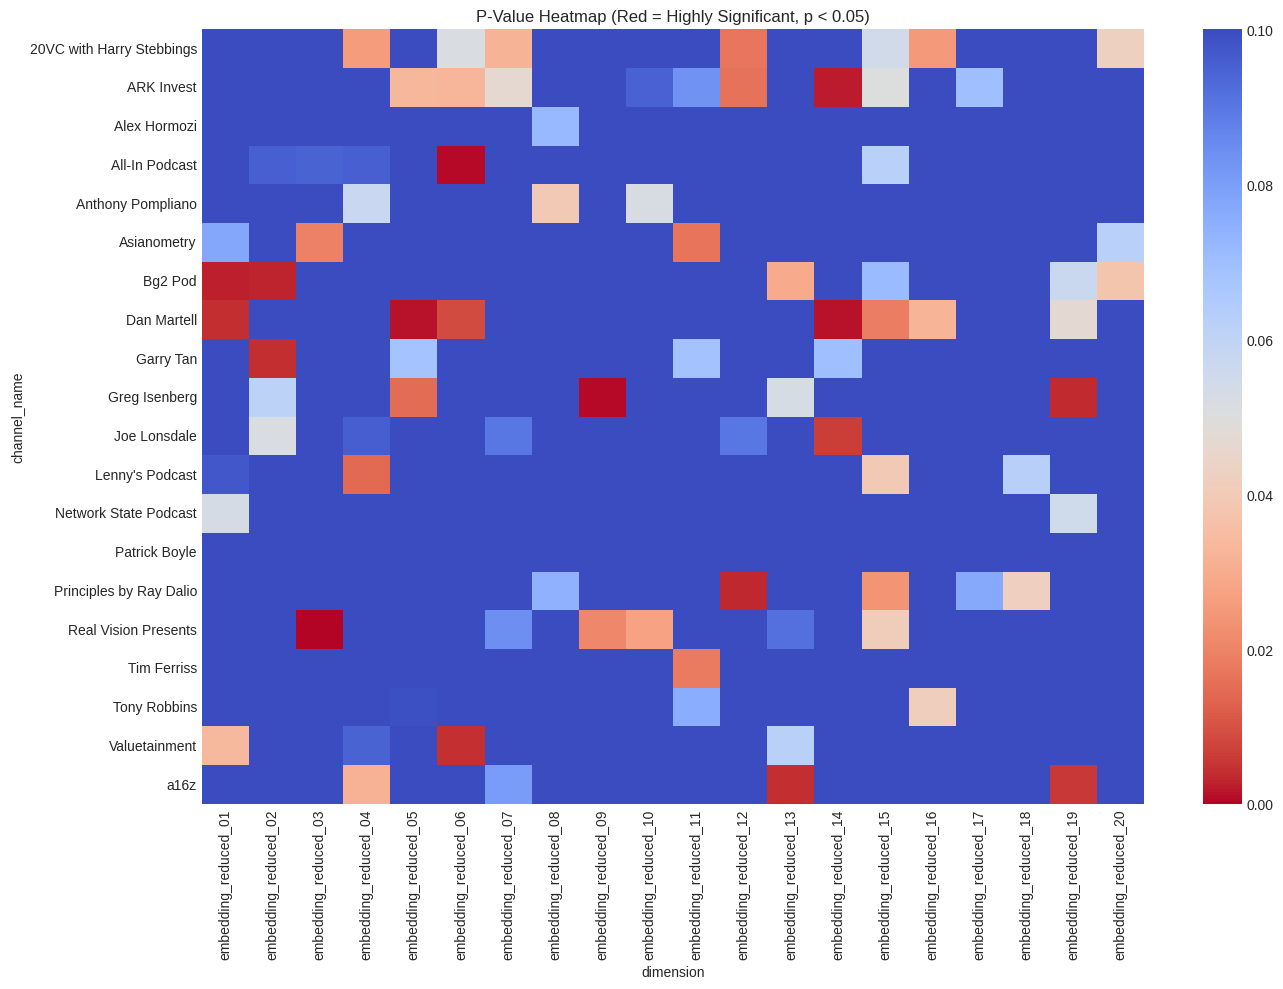

In [5]:
if not results_df.empty:
    # 1. Bar chart of significance percentage per dimension
    plt.figure(figsize=(10, 6))
    sns.barplot(data=dim_summary, x='significant_pct', y='dimension', color='steelblue')
    plt.title('Percentage of Channels Where Each Dimension is Significant (p < 0.05)')
    plt.xlabel('% of Channels')
    plt.ylabel('Dimension')
    plt.tight_layout()
    plt.show()

    # 2. Heatmap of p-values per channel and dimension (Top 20 channels by R2 adj)
    top_channels = results_df[['channel_name', 'r2_adj']].drop_duplicates().sort_values('r2_adj', ascending=False).head(20)['channel_name']
    heatmap_data = results_df[results_df['channel_name'].isin(top_channels)].pivot(index='channel_name', columns='dimension', values='p_value')

    # Sort columns by dimension number for better readability if they are named consistently
    try:
        sorted_cols = sorted(heatmap_data.columns, key=lambda x: int(x.split('_')[-1]))
        heatmap_data = heatmap_data[sorted_cols]
    except:
        pass

    plt.figure(figsize=(14, 10))
    sns.heatmap(heatmap_data, cmap='coolwarm_r', vmin=0, vmax=0.1, annot=False)
    plt.title('P-Value Heatmap (Red = Highly Significant, p < 0.05)')
    plt.tight_layout()
    plt.show()
